In [ ]:
import os
import glob
import cv2 as cv
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from torch.utils.data import Dataset
from uniclothdiff.registry import build_dataset

# UniClothDiff specific imports
from uniclothdiff.registry import build_model
from uniclothdiff.pipelines.cloth_state_est_pipeline import ClothStateEstPipeline
from diffusers import DDPMScheduler


CHECKPOINT_DIR = "../experiments/full_mode/checkpoints/checkpoint-66000"
CONFIG_PATH = "../configs/train_state_est_full.yaml"
TEMPLATE_PATH = "../../TRTM/datasets/template_square/template_square.pickle"
TRTM_DATA_PATH = "../../TRTM/datasets/template_square"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def load_trained_model(config_path, checkpoint_dir, device):
    """Rebuilds the architecture and loads the trained weights natively."""
    print("Loading configuration...")
    config = OmegaConf.load(config_path)
    
    # 1. Build a dummy model just to get the correct Python Class 
    dummy_model = build_model(OmegaConf.to_container(config.model_cfg))
    ModelClass = type(dummy_model)
    
    # 2. Use Diffusers' native loading method
    print(f"Loading weights from {checkpoint_dir}/model ...")
    model = ModelClass.from_pretrained(checkpoint_dir, subfolder="model")
    model.to(device)
    model.eval()
    print("Weights loaded successfully!")
    
    # 3. Initialize the Diffusion Pipeline
    # Grab the diffusion_cfg instead of scheduler_cfg
    diff_dict = OmegaConf.to_container(config.diffusion_cfg)
    
    # Pop the custom 'type' key so Hugging Face doesn't crash
    if 'type' in diff_dict:
        diff_dict.pop('type')
        
    scheduler = DDPMScheduler(**diff_dict)
    pipeline = ClothStateEstPipeline(model=model, scheduler=scheduler)
    pipeline.to(device)
    
    return pipeline

def load_template_and_data(template_path):
    with open(template_path, 'rb') as f:
        template = pickle.load(f)
    q_temp = torch.tensor(template['mesh_pos'], dtype=torch.float32).unsqueeze(0)
    return q_temp.to(DEVICE)

def extract_80_point_contour(mesh_441):
    """Slices the full 441-point ground truth mesh down to the 80-point boundary ring."""
    grid_size = 21
    indices = np.arange(grid_size * grid_size).reshape(grid_size, grid_size)
    contour_idx = np.concatenate([indices[0, :], indices[1:-1, -1], indices[-1, :][::-1], indices[1:-1, 0][::-1]])
    return mesh_441[contour_idx]

def _set_axes_equal(ax):
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    origin = np.mean(limits, axis=1)
    radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
    ax.set_xlim3d([origin[0] - radius, origin[0] + radius])
    ax.set_ylim3d([origin[1] - radius, origin[1] + radius])
    ax.set_zlim3d([origin[2] - radius, origin[2] + radius])

def plot_3d_results(input_pcd, pred_contour, gt_contour=None):
    fig = plt.figure(figsize=(18, 6))
    
    # Close the loops for plotting
    pred_loop = np.vstack([pred_contour, pred_contour[0]])
    
    # Plot 1: Input Point Cloud
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.set_title("Input Point Cloud")
    ax1.scatter(input_pcd[:, 0], input_pcd[:, 1], input_pcd[:, 2], c='gray', s=2, alpha=0.5)
    _set_axes_equal(ax1)
    
    # # Plot 2: Predicted 80-Point Contour
    # ax2 = fig.add_subplot(132, projection='3d')
    # ax2.set_title("Predicted Cloth Boundary")
    # ax2.plot(pred_loop[:, 0], pred_loop[:, 1], pred_loop[:, 2], c='blue', linewidth=2.5, label='Prediction')
    # ax2.scatter(pred_contour[:, 0], pred_contour[:, 1], pred_contour[:, 2], c='cyan', s=10)
    # _set_axes_equal(ax2)
    # ax2.legend()

    # Plot 3: Overlay
    ax3 = fig.add_subplot(132, projection='3d')
    ax3.set_title("Prediction vs Ground Truth")
    ax3.scatter(input_pcd[:, 0], input_pcd[:, 1], input_pcd[:, 2], c='gray', s=1, alpha=0.1)
    ax3.plot(pred_loop[:, 0], pred_loop[:, 1], pred_loop[:, 2], c='blue', linewidth=2.5, label='Predicted Edge')
    
    # ONLY plot ground truth if it actually exists!
    if gt_contour is not None:
        gt_loop = np.vstack([gt_contour, gt_contour[0]])
        ax3.plot(gt_loop[:, 0], gt_loop[:, 1], gt_loop[:, 2], c='red', linewidth=2, linestyle='--', label='Ground Truth Edge')
        
    _set_axes_equal(ax3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def plot_full_mesh_results(depth_image, input_pcd, pred_mesh):
    fig = plt.figure(figsize=(18, 6))
    
    # Plot 1: The 2D Depth Image (Raw Sensor Input)
    ax1 = fig.add_subplot(131)
    ax1.set_title("Input Depth Image (PNG)")
    # Convert BGR to RGB if it was loaded with cv2
    if len(depth_image.shape) == 3:
        depth_image = cv.cvtColor(depth_image, cv.COLOR_BGR2RGB)
    ax1.imshow(depth_image)
    ax1.axis('off')
    
    # Plot 2: Input Point Cloud (Top-Down)
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.set_title("Input Point Cloud (Top-Down)")
    ax2.scatter(input_pcd[:, 0], input_pcd[:, 1], input_pcd[:, 2], c='gray', s=2, alpha=0.5)
    _set_axes_equal(ax2)
    # --- MAGIC LINE FOR TOP-DOWN VIEW ---
    ax2.view_init(elev=90, azim=-90) 
    
    # Plot 3: Predicted Full 441-Point Cloth Mesh (Top-Down)
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.set_title("Predicted Cloth Mesh (Top-Down)")
    ax3.scatter(pred_mesh[:, 0], pred_mesh[:, 1], pred_mesh[:, 2], c='blue', s=15, depthshade=True)
    _set_axes_equal(ax3)
    # --- MAGIC LINE FOR TOP-DOWN VIEW ---
    ax3.view_init(elev=90, azim=-90) 

    plt.tight_layout()
    plt.show()


In [16]:
if __name__ == "__main__":
    # 1. Load Model & Template
    pipeline = load_trained_model(CONFIG_PATH, CHECKPOINT_DIR, DEVICE)
    q_temp = load_template_and_data(TEMPLATE_PATH)
    config = OmegaConf.load(CONFIG_PATH) # Load config for the dataset
    
    # 2. Load Test Dataset using UniClothDiff's Registry!
    print("Loading test data...")
    dataset_cfg = OmegaConf.to_container(config.dataset_cfg)
    
    # Override the config to force it to load Real Test data
    dataset_cfg['phase'] = 'test'
    dataset_cfg['use_real'] = True
    dataset_cfg['use_simu'] = False
    
    test_dataset = build_dataset(dataset_cfg)
    sample = test_dataset[0] # Grab the first test sample
    
    print("New Sample Keys:", sample.keys())
    
    # Grab the raw 2D depth image for the left plot
    depth_img = sample['image_real'] 
    
    # 3. Extract Ground Truth Contour (if it exists)
    if 'mesh_simu' in sample:
        full_gt_mesh = sample['mesh_simu']
        gt_contour = extract_80_point_contour(full_gt_mesh)
    else:
        gt_contour = None
    
    # 4. Handle Input Point Cloud
    # Because we used build_dataset, sample['pcd'] should now automatically exist!
    if 'pcd' in sample:
        print("Success! Point cloud found.")
        input_pcd = torch.tensor(sample['pcd'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    else:
        raise ValueError("The dataset wrapper failed to generate 'pcd'. Check TRTMDiffusionDataset!")
    
    # 5. Diffusion Inference
    print("Running Diffusion Inference (20 steps)...")
    with torch.no_grad():
        output = pipeline(
            encoder_hidden_states=input_pcd,
            q_temp=q_temp,
            shape=(1, 441, 3), 
            num_inference_steps=20,
            do_classifier_free_guidance=False,
            call_v2=True
        )
        
    # Extract FULL prediction
    predicted_full_mesh = output[0][0] # Shape [441, 3]
    pcd_numpy = input_pcd[0].cpu().numpy()
    
    print("Inference Complete! Plotting...")
    plot_full_mesh_results(depth_img, pcd_numpy, predicted_full_mesh)

Loading configuration...


Loading weights from ../experiments/full_mode/checkpoints/checkpoint-66000/model ...
Weights loaded successfully!
Loading test data...
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


TypeError: __init__() got an unexpected keyword argument 'phase'

/home/cjimenez/Projects/Tracking/Code/TrackAnyCloth/UniClothDiff/third_party/diffusers/src/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


Loading configuration...
Loading weights from ../experiments/full_mode/checkpoints/checkpoint-70000/model ...
Loading test data...
Notebook Dataset loaded 1440 REAL test images from ../../TRTM/datasets/template_square/real/test
1440
Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


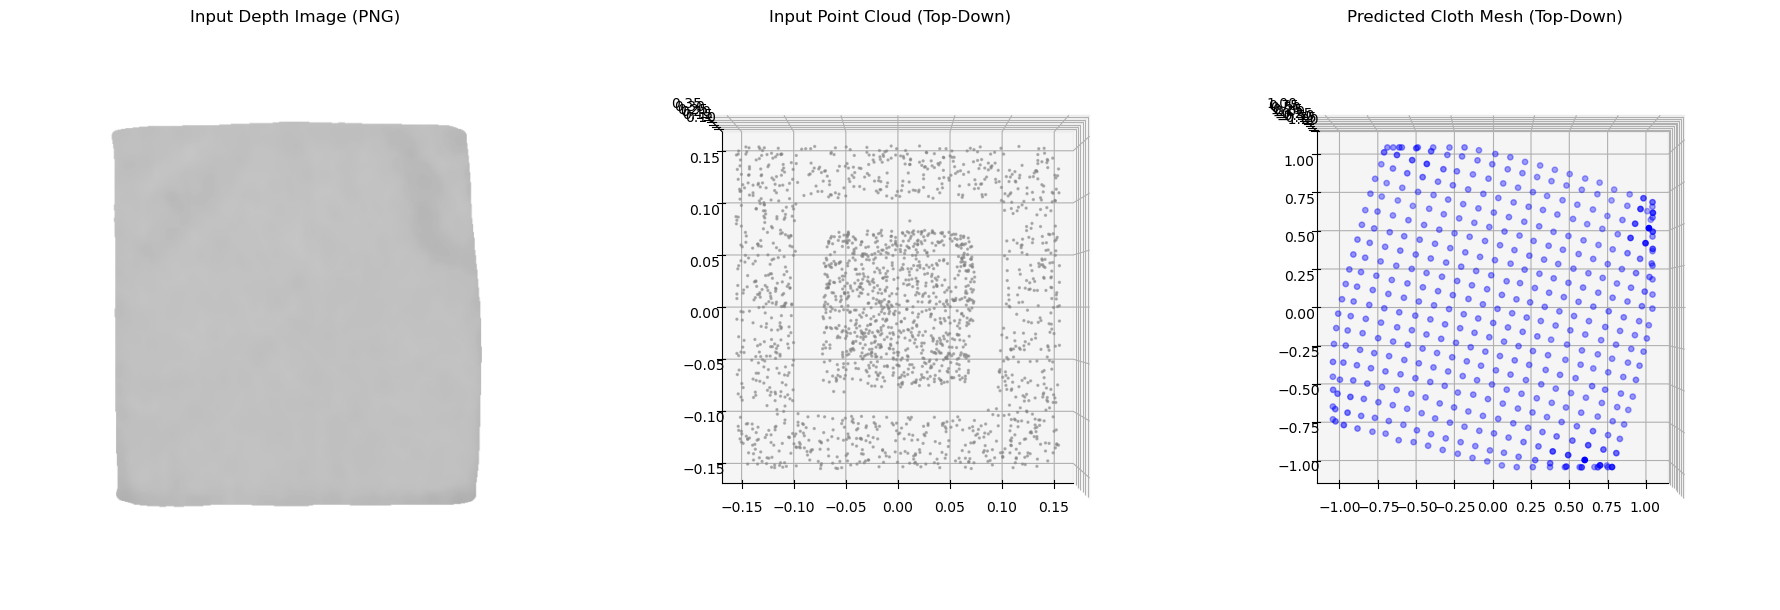

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


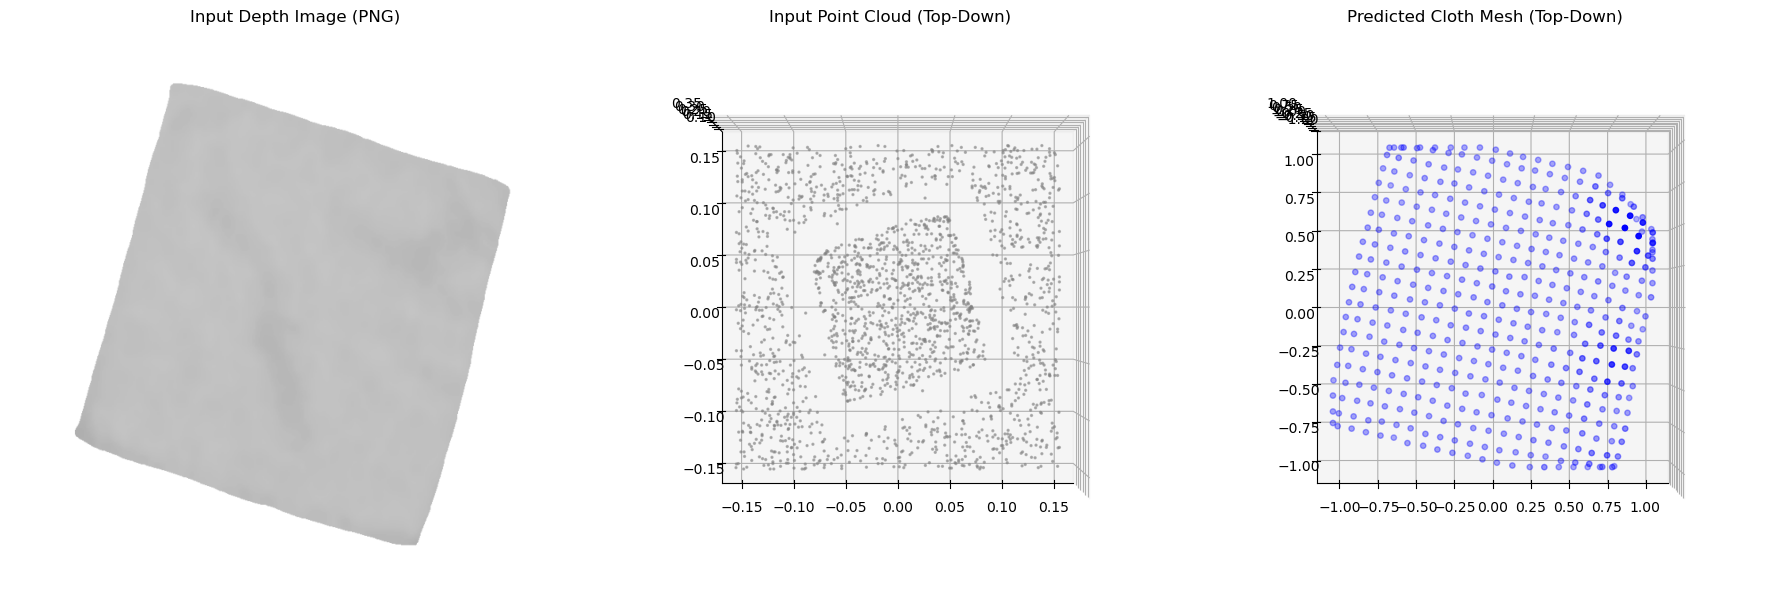

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


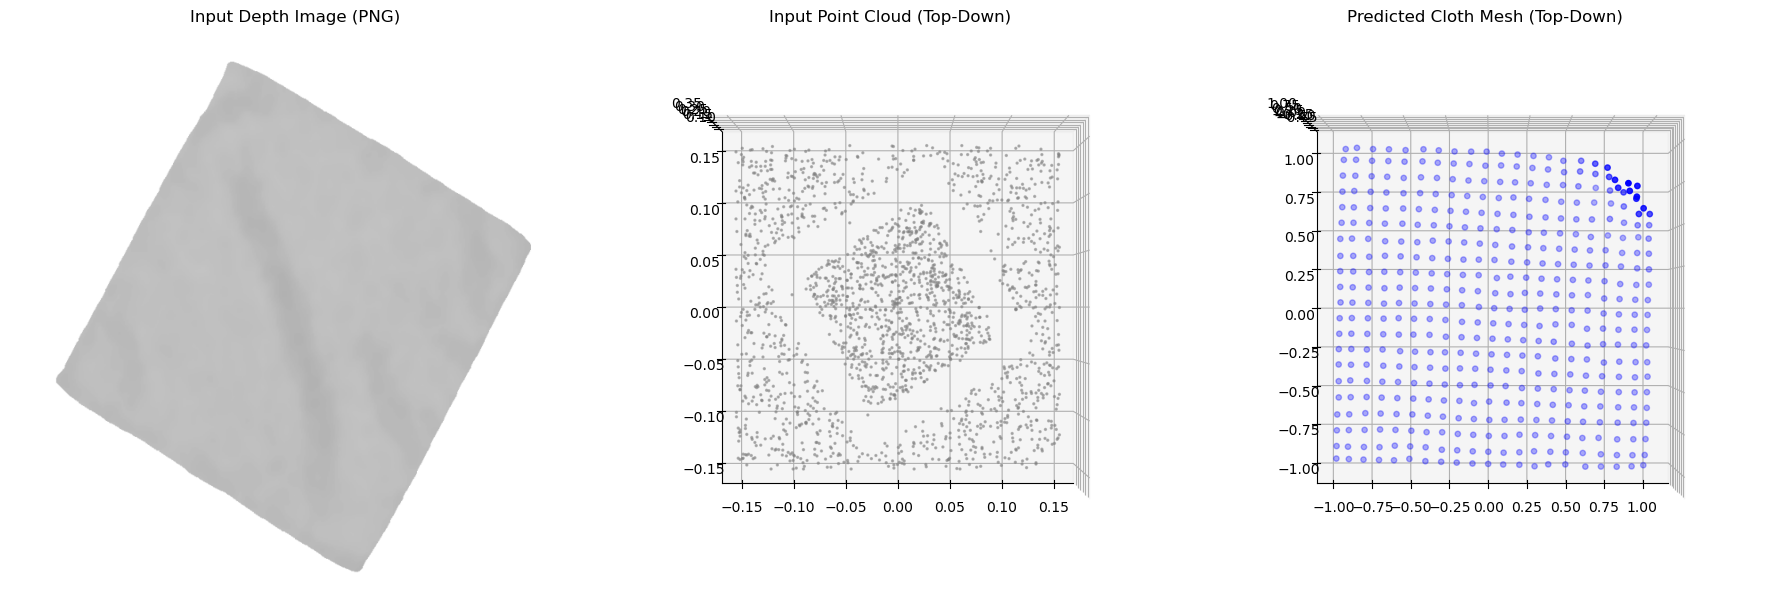

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


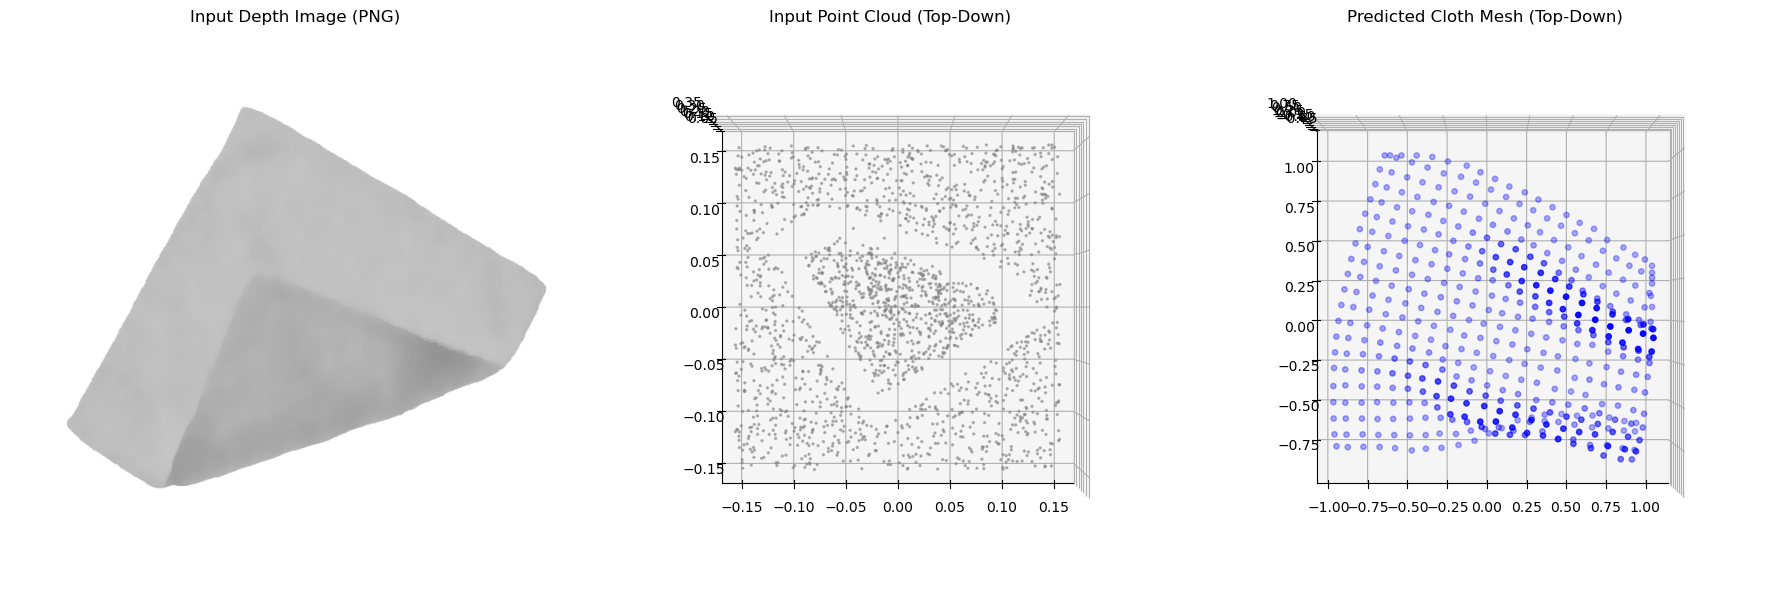

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


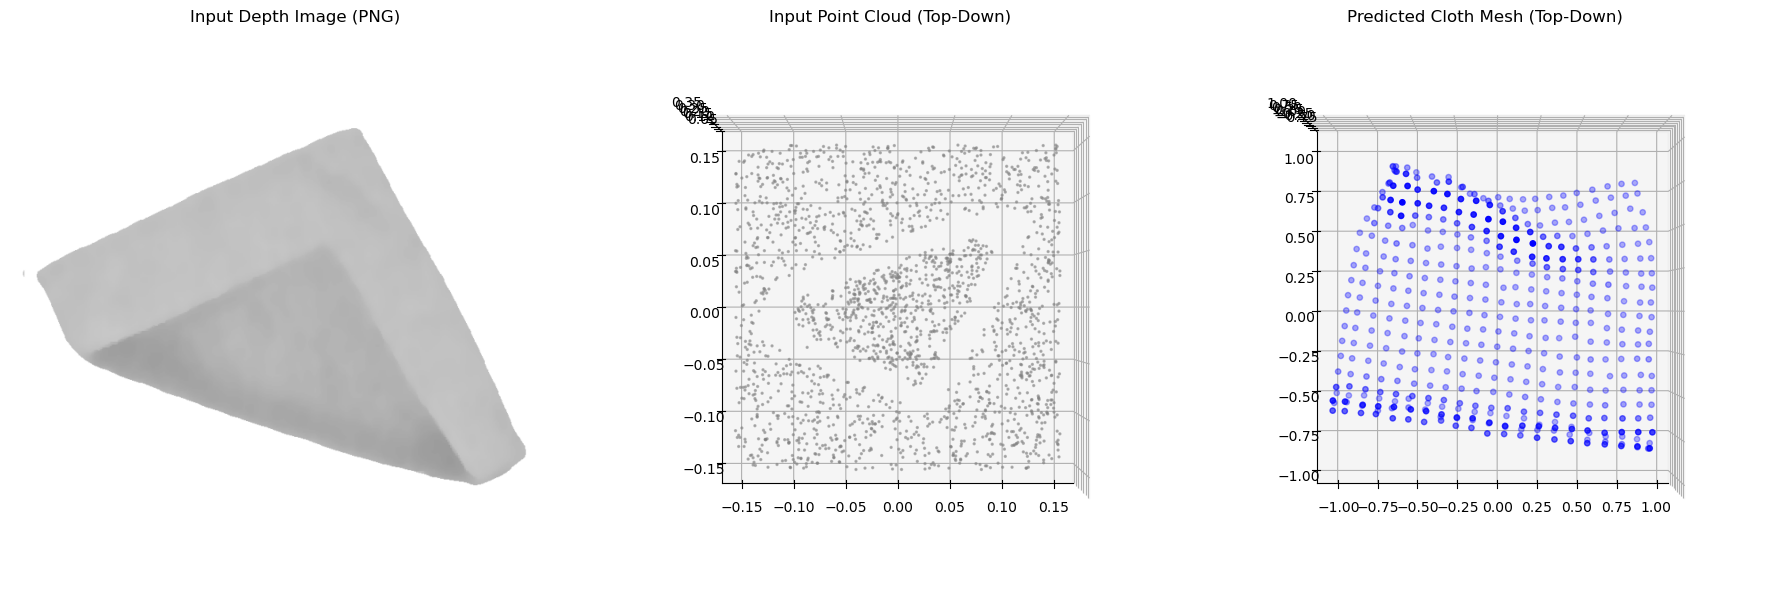

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


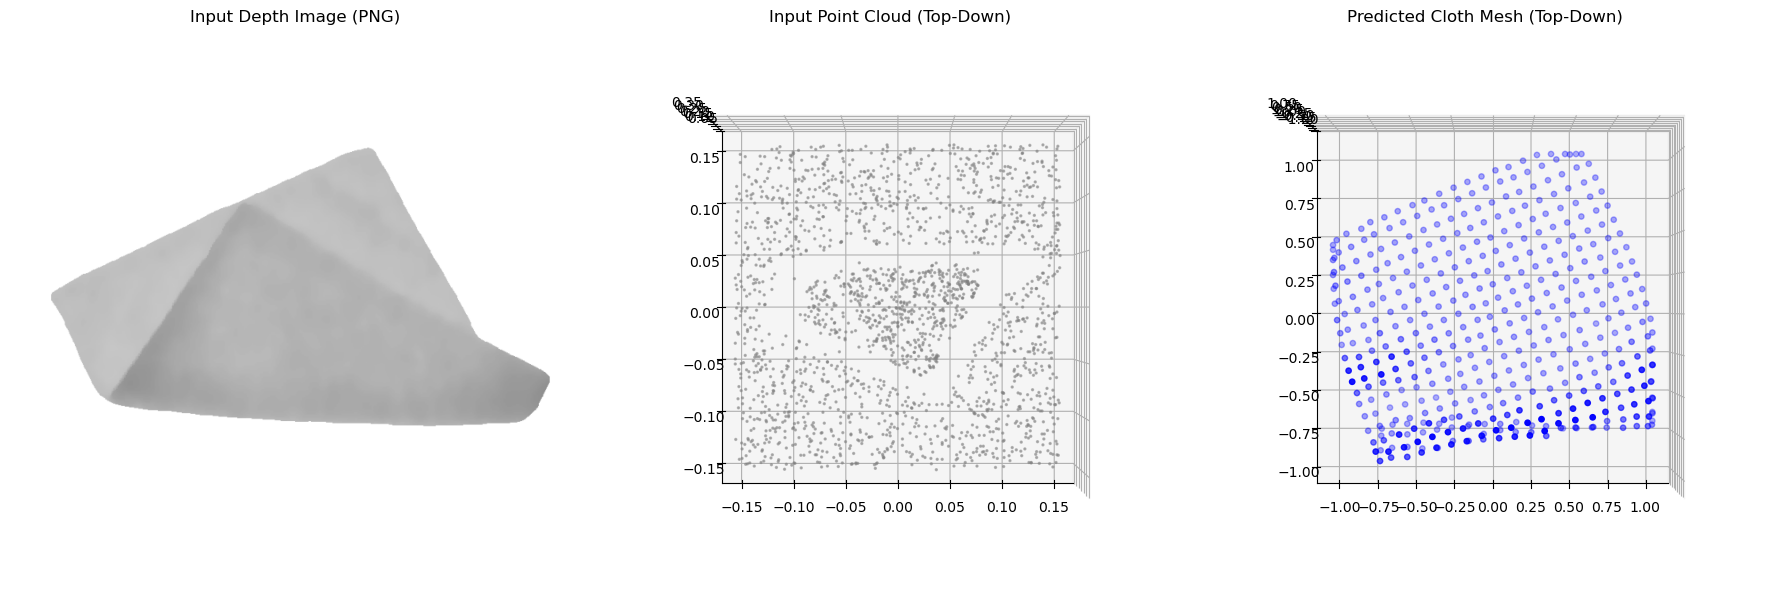

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


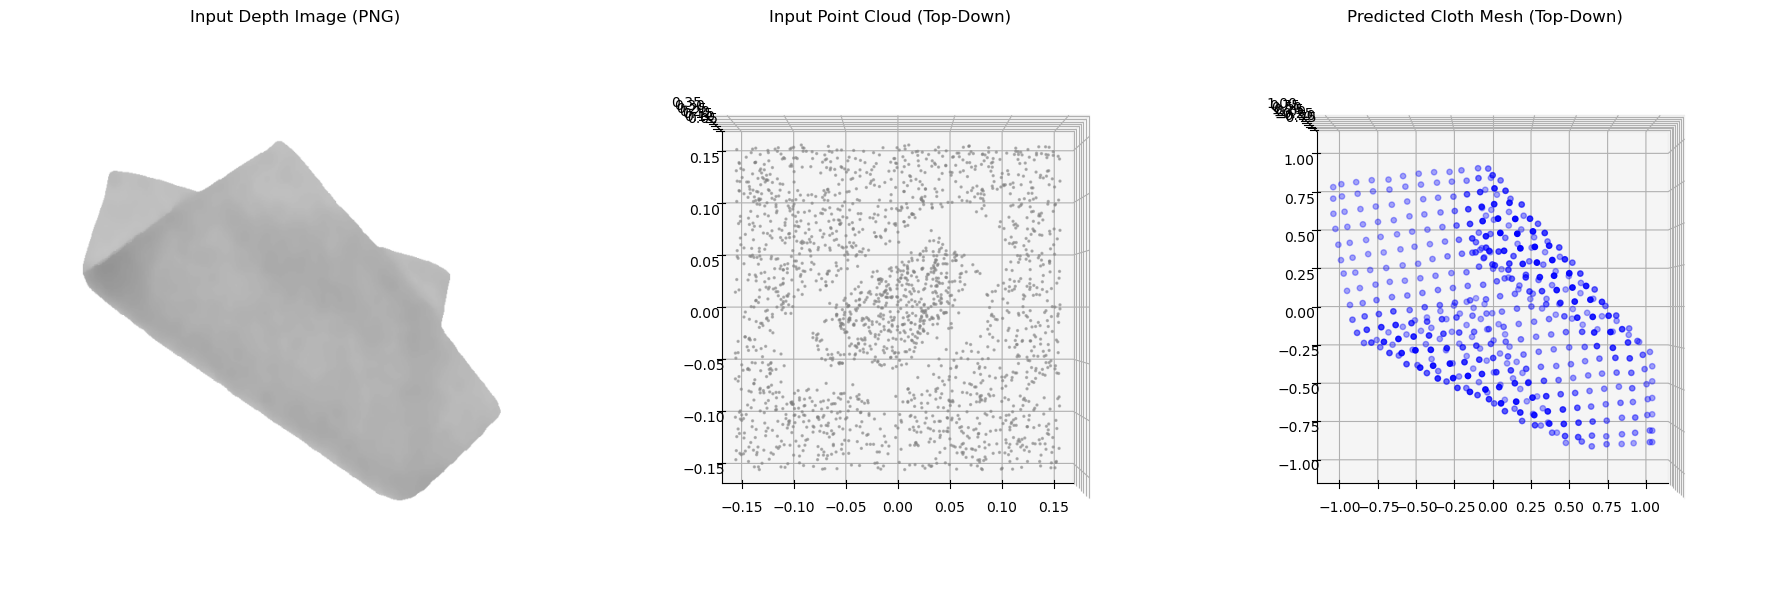

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


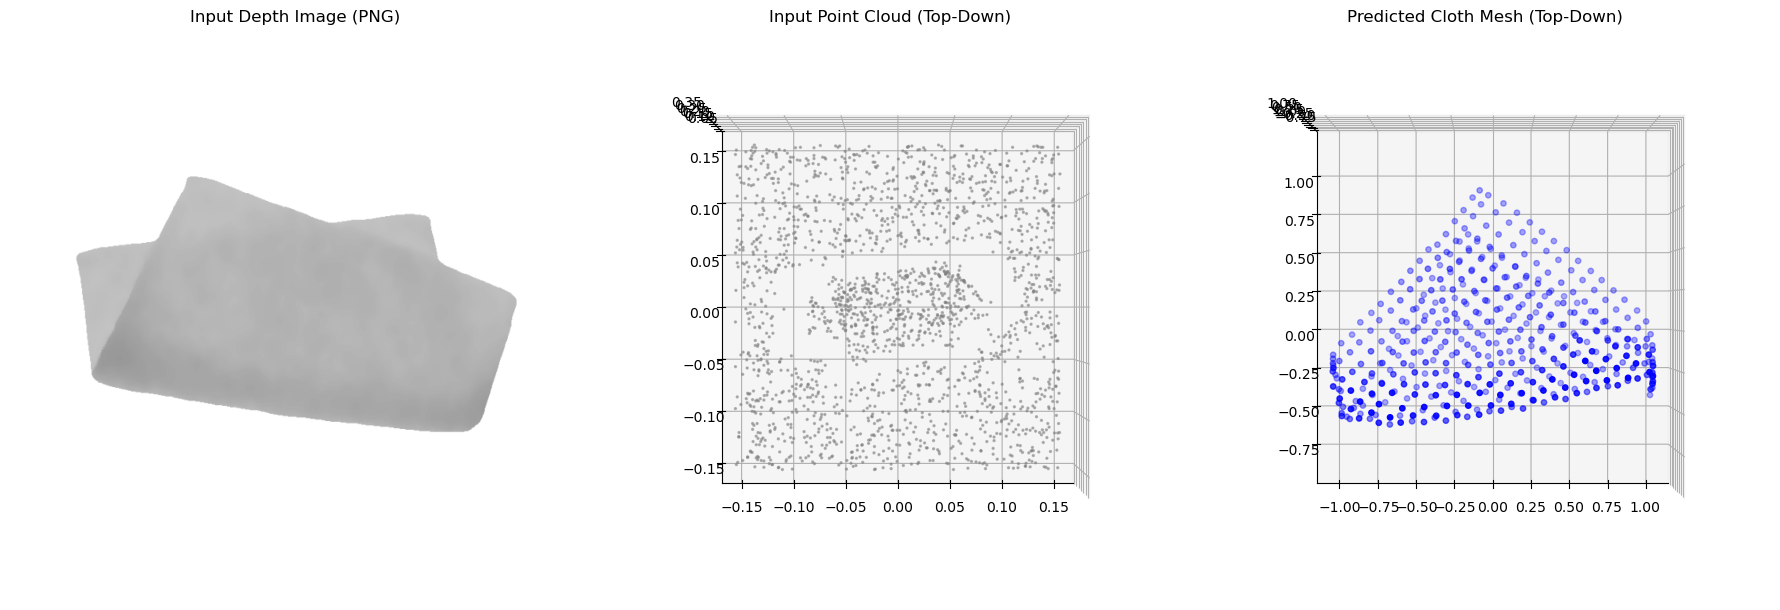

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


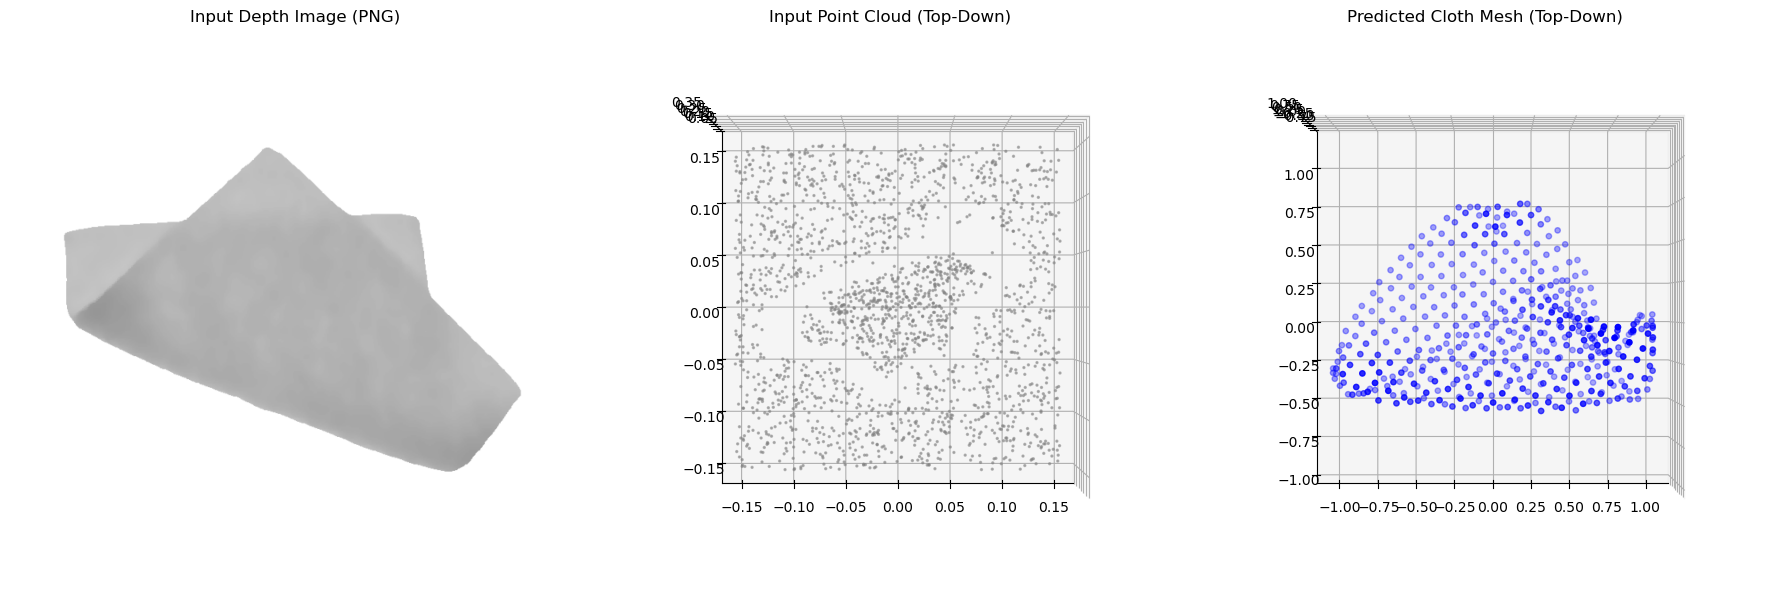

Running Diffusion Inference (20 steps)...


  0%|          | 0/100 [00:00<?, ?it/s]

Inference Complete! Plotting...


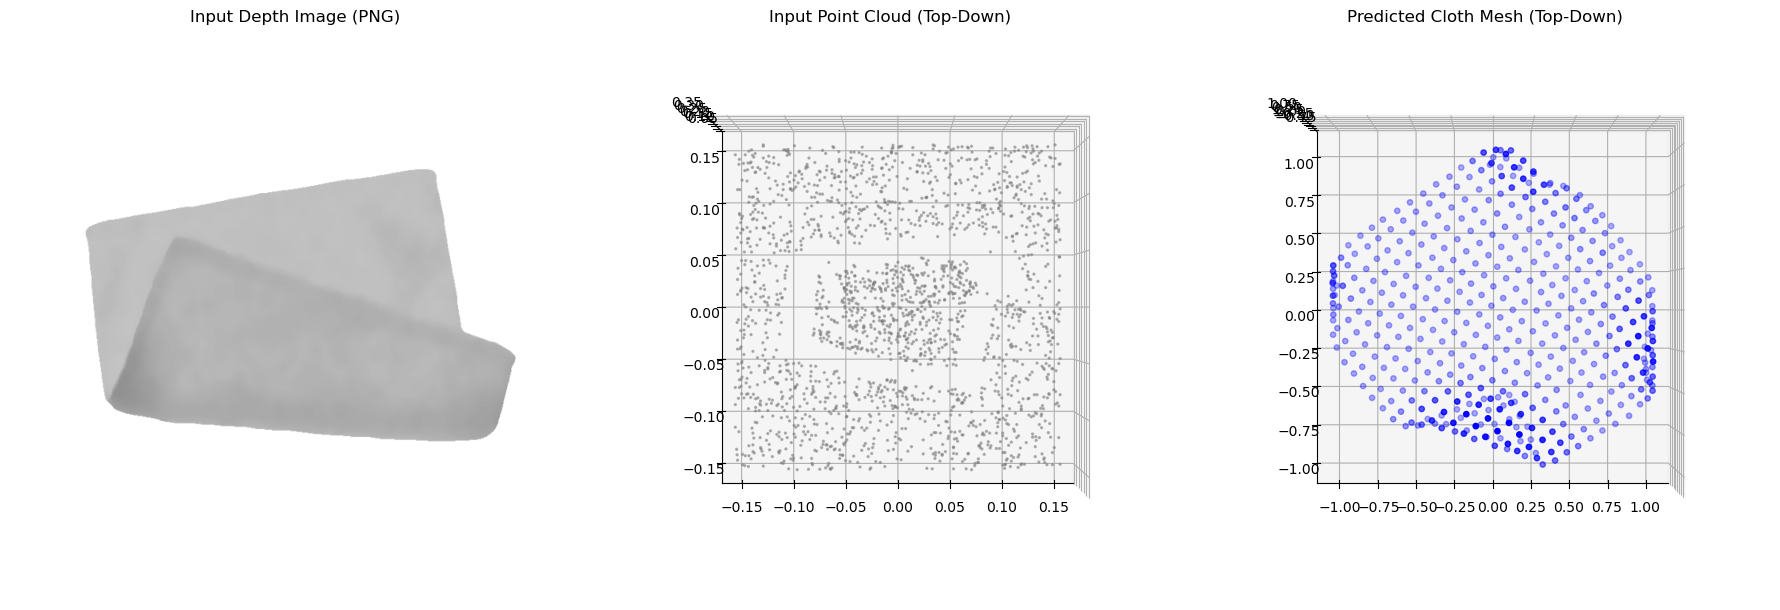

In [1]:
import os
import glob
import cv2
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from torch.utils.data import Dataset

# UniClothDiff specific imports
from uniclothdiff.registry import build_model
from uniclothdiff.pipelines.cloth_state_est_pipeline import ClothStateEstPipeline
from diffusers import DDPMScheduler

# ==========================================
# 1. SETUP PATHS
# ==========================================
TRAIN_MODE = "full"
CHECKPOINT_DIR = "../experiments/trtm_edge_input/checkpoints/checkpoint-70000" if TRAIN_MODE == "edge_input" else "../experiments/full_mode/checkpoints/checkpoint-70000"
CONFIG_PATH = "../configs/train_state_est_edge.yaml" if TRAIN_MODE == "edge_input" else "../configs/train_state_est_full.yaml"
TEMPLATE_PATH = "../../TRTM/datasets/template_square/template_square_edge.pickle" if TRAIN_MODE == "edge_input" else "../../TRTM/datasets/template_square/template_square.pickle"
TRTM_DATA_PATH = "../../TRTM/datasets/template_square" 

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 2. STANDALONE NOTEBOOK DATASET (Handles Real Data Perfectly)
# ==========================================
class NotebookRealClothDataset(Dataset):
    def __init__(self, data_path, phase='test', num_sample_points=2048):
        self.data_path = data_path
        self.phase = phase
        self.num_sample_points = num_sample_points
        
        # Look specifically in the 'real' folder for depth pngs
        self.real_dir = os.path.join(data_path, 'real', phase)
        self.data_files = sorted(glob.glob(os.path.join(self.real_dir, "*.real_depth.png")))
        self.num_samples = len(self.data_files)
        
        print(f"Notebook Dataset loaded {self.num_samples} REAL test images from {self.real_dir}")

        # TRTM Camera Intrinsics
        self.camera_params = {
            'cx': 360.0, 'cy': 360.0,
            'fx': 360.0 / np.tan(np.deg2rad(60) / 2),
            'fy': 360.0 / np.tan(np.deg2rad(60) / 2)
        }

    def depth_to_point_cloud(self, depth):
        height, width = depth.shape[:2] 
        if len(depth.shape) > 2:
            depth = depth[:, :, 0]
            
        x, y = np.meshgrid(np.arange(width), np.arange(height))
        z = depth.astype(np.float32) / 1000.0 # Convert mm to meters
        
        x_norm = (x - self.camera_params['cx']) / self.camera_params['fx']
        y_norm = (y - self.camera_params['cy']) / self.camera_params['fy']
        
        x_3d = x_norm * z
        y_3d = y_norm * z
        
        mask = (z > 0) & (z < 2.0) # Filter out background/noise
        points = np.stack([x_3d[mask], y_3d[mask], z[mask]], axis=1)
        return points

    def sample_points(self, pcd):
        num_points = pcd.shape[0]
        if num_points == 0:
            return np.zeros((self.num_sample_points, 3))
        if num_points == self.num_sample_points:
            return pcd
        elif num_points > self.num_sample_points:
            # Randomly downsample
            indices = np.random.choice(num_points, self.num_sample_points, replace=False)
            return pcd[indices]
        else:
            # Randomly upsample (pad)
            indices = np.random.choice(num_points, self.num_sample_points, replace=True)
            return pcd[indices]  

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        depth_path = self.data_files[idx]
        depth_img = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
        
        # Unproject depth to 3D and sample exactly 2048 points
        points_3d = self.depth_to_point_cloud(depth_img)
        points_sampled = self.sample_points(points_3d)
        
        return {
            'image_real': depth_img, 
            'pcd': points_sampled
        }

def load_trained_model(config_path, checkpoint_dir, device):
    print("Loading configuration...")
    config = OmegaConf.load(config_path)
    
    dummy_model = build_model(OmegaConf.to_container(config.model_cfg))
    ModelClass = type(dummy_model)
    
    print(f"Loading weights from {checkpoint_dir}/model ...")
    model = ModelClass.from_pretrained(checkpoint_dir, subfolder="model")
    model.to(device)
    model.eval()
    
    diff_dict = OmegaConf.to_container(config.diffusion_cfg)
    if 'type' in diff_dict:
        diff_dict.pop('type')
        
    scheduler = DDPMScheduler(**diff_dict)
    pipeline = ClothStateEstPipeline(model=model, scheduler=scheduler)
    pipeline.to(device)
    return pipeline

def load_template_and_data(template_path):
    with open(template_path, 'rb') as f:
        template = pickle.load(f)
    q_temp = torch.tensor(template['mesh_pos'], dtype=torch.float32).unsqueeze(0)
    return q_temp.to(DEVICE)

def _set_axes_equal(ax):
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    origin = np.mean(limits, axis=1)
    radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
    ax.set_xlim3d([origin[0] - radius, origin[0] + radius])
    ax.set_ylim3d([origin[1] - radius, origin[1] + radius])
    ax.set_zlim3d([origin[2] - radius, origin[2] + radius])

def plot_full_mesh_results(depth_image, input_pcd, pred_mesh):
    fig = plt.figure(figsize=(18, 6))
    
    # Plot 1: 2D Depth Image
    ax1 = fig.add_subplot(131)
    ax1.set_title("Input Depth Image (PNG)")
    if len(depth_image.shape) == 3:
        depth_image = cv2.cvtColor(depth_image, cv2.COLOR_BGR2RGB)
    ax1.imshow(depth_image, cmap='gray' if len(depth_image.shape)==2 else None)
    ax1.axis('off')
    
    # Plot 2: Input Point Cloud (Top-Down)
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.set_title("Input Point Cloud (Top-Down)")
    ax2.scatter(input_pcd[:, 0], input_pcd[:, 1], input_pcd[:, 2], c='gray', s=2, alpha=0.5)
    _set_axes_equal(ax2)
    ax2.view_init(elev=90, azim=-90) 
    
    # Plot 3: Predicted Full Mesh (Top-Down)
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.set_title("Predicted Cloth Mesh (Top-Down)")
    ax3.scatter(pred_mesh[:, 0], pred_mesh[:, 1], pred_mesh[:, 2], c='blue', s=15, depthshade=True)
    _set_axes_equal(ax3)
    ax3.view_init(elev=90, azim=-90) 

    plt.tight_layout()
    plt.show()

def plot_edge_results(depth_image, input_pcd, pred_contour):
    fig = plt.figure(figsize=(18, 6))
    
    # Close the loop for plotting (connect point 79 back to point 0)
    pred_loop = np.vstack([pred_contour, pred_contour[0]])
    
    # Plot 1: 2D Depth Image
    ax1 = fig.add_subplot(131)
    ax1.set_title("Input Depth Image (PNG)")
    if len(depth_image.shape) == 3:
        depth_image = cv2.cvtColor(depth_image, cv2.COLOR_BGR2RGB)
    ax1.imshow(depth_image, cmap='gray' if len(depth_image.shape)==2 else None)
    ax1.axis('off')
    
    # Plot 2: Input Point Cloud (Top-Down)
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.set_title("Input Point Cloud (Top-Down)")
    ax2.scatter(input_pcd[:, 0], input_pcd[:, 1], input_pcd[:, 2], c='gray', s=2, alpha=0.5)
    _set_axes_equal(ax2)
    ax2.view_init(elev=90, azim=-90) 
    
    # Plot 3: Predicted Cloth Boundary (Top-Down)
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.set_title("Predicted Cloth Boundary (80 points)")
    # Plot the line connecting the edges
    ax3.plot(pred_loop[:, 0], pred_loop[:, 1], pred_loop[:, 2], c='blue', linewidth=2.5)
    # Plot the actual 80 nodes as dots
    ax3.scatter(pred_contour[:, 0], pred_contour[:, 1], pred_contour[:, 2], c='cyan', s=15)
    _set_axes_equal(ax3)
    ax3.view_init(elev=90, azim=-90) 

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. RUN INFERENCE
# ==========================================
if __name__ == "__main__":
    pipeline = load_trained_model(CONFIG_PATH, CHECKPOINT_DIR, DEVICE)
    q_temp = load_template_and_data(TEMPLATE_PATH)
    
    # 2. Load Real Test Data
    print("Loading test data...")
    test_dataset = NotebookRealClothDataset(data_path=TRTM_DATA_PATH, phase='test', num_sample_points=2048)

    print(len(test_dataset))
    
    # Grab a sample (change this index to look at different images!)
    for i in range(10):
        sample = test_dataset[i] 
        
        depth_img = sample['image_real'] 
        input_pcd = torch.tensor(sample['pcd'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        
        # 3. Diffusion Inference
        print("Running Diffusion Inference (20 steps)...")
        with torch.no_grad():
            output = pipeline(
                encoder_hidden_states=input_pcd,
                q_temp=q_temp,
                shape=(1, 441, 3) if TRAIN_MODE == 'full' else (1, 80, 3),
                num_inference_steps=100,
                do_classifier_free_guidance=False,
                call_v2=True
            )
            
        predicted_full_mesh = output[0][0] # Shape [441, 3]
        pcd_numpy = input_pcd[0].cpu().numpy()
        
        print("Inference Complete! Plotting...")

        if TRAIN_MODE == "edge_input":
            # pred_contour = predicted_full_mesh.cpu().numpy()
            plot_edge_results(depth_img, pcd_numpy, predicted_full_mesh)
        else:
            plot_full_mesh_results(depth_img, pcd_numpy, predicted_full_mesh)

In [2]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 17.2 MB/s eta 0:00:00a 0:00:01


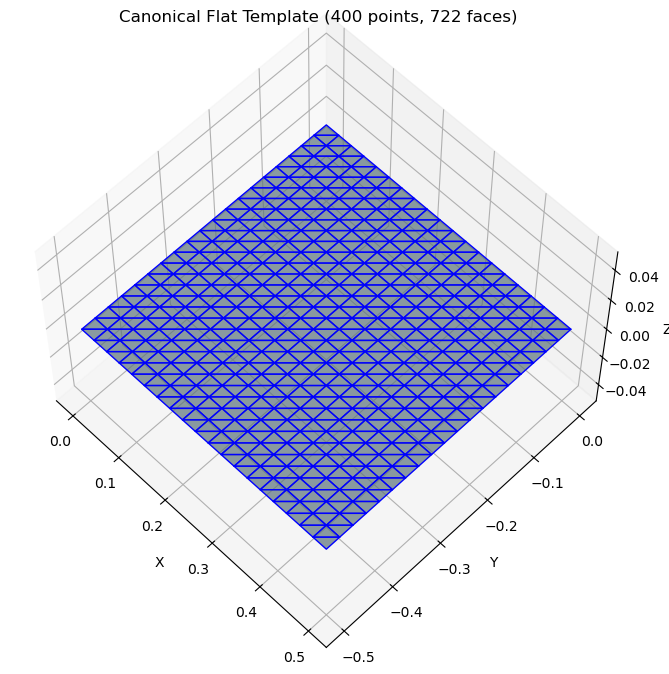

In [3]:
import matplotlib.pyplot as plt
import trimesh

# 1. Load the flat template you just generated
mesh = trimesh.load('../assets/vr_template_d1_400.obj')

# 2. Set up the Matplotlib 3D figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot the vertices and faces
ax.plot_trisurf(
    mesh.vertices[:, 0], 
    mesh.vertices[:, 1], 
    mesh.vertices[:, 2], 
    triangles=mesh.faces, 
    color='lightblue',   # Color of the cloth surface
    edgecolor='blue',    # Color of the thread connections
    alpha=0.7
)

# 4. Clean up the camera angle and axes
ax.view_init(elev=60, azim=-45)
ax.set_title(f"Canonical Flat Template ({len(mesh.vertices)} points, {len(mesh.faces)} faces)")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot inside the notebook cell
plt.show()